In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# %pip install --quiet seaborn shap
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, KFold
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import (RandomForestRegressor, GradientBoostingRegressor,
                               ExtraTreesRegressor, VotingRegressor)
from sklearn.tree import DecisionTreeRegressor
from sklearn.inspection import permutation_importance
import xgboost as xgb
import lightgbm as lgb
import joblib
import shap

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
df = pd.read_csv('airbnb_processed_data_multimodal.csv')
print(f"Loaded dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Drop text_quality_percentile — computed on full dataset in preprocessing
# so retaining it would constitute data leakage into the test set
if 'text_quality_percentile' in df.columns:
    df = df.drop(columns=['text_quality_percentile'])
    print("Dropped text_quality_percentile (preprocessing leakage)")

# Safety check — price_per_person must not be present
if 'price_per_person' in df.columns:
    df = df.drop(columns=['price_per_person'])
    print("Dropped price_per_person (data leakage)")

print(f"\nFinal shape after safety drops: {df.shape}")

Loaded dataset shape: (6562, 292)
Memory usage: 9.10 MB
Dropped text_quality_percentile (preprocessing leakage)

Final shape after safety drops: (6562, 291)


In [3]:
def get_feature_groups(columns):
    bert_name   = [c for c in columns if c.startswith('name_bert_')]
    bert_desc   = [c for c in columns if c.startswith('desc_bert_')]
    resnet      = [c for c in columns if c.startswith('img_resnet_')]
    has_picture = [c for c in columns if c == 'has_picture']

    deep_learning_cols = set(bert_name + bert_desc + resnet + has_picture)
    structured = [c for c in columns
                  if c not in deep_learning_cols and c != 'price']

    print(f"Structured features:  {len(structured)}")
    print(f"BERT name features:   {len(bert_name)}")
    print(f"BERT desc features:   {len(bert_desc)}")
    print(f"ResNet50 features:    {len(resnet)}")
    print(f"has_picture:          {len(has_picture)}")

    return {
        'structured': structured,
        'bert_name':  bert_name,
        'bert_desc':  bert_desc,
        'resnet':     resnet,
        'has_picture':has_picture
    }

feature_groups = get_feature_groups(df.columns.tolist())

Structured features:  193
BERT name features:   32
BERT desc features:   32
ResNet50 features:    32
has_picture:          1


In [4]:
target_col = 'price'
X = df.drop(columns=[target_col])
y = df[target_col]

print(f"Features: {X.shape[1]}  |  Samples: {X.shape[0]}")
print(f"\nTarget statistics:")
print(y.describe())

# ── Split FIRST ──────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(f"\nTraining set:   {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set:       {X_test.shape}")

# ── Fill missing values using TRAIN statistics only ───────────────────────────
train_median = X_train.median()
X_train = X_train.fillna(train_median)
X_val   = X_val.fillna(train_median)
X_test  = X_test.fillna(train_median)


Features: 290  |  Samples: 6562

Target statistics:
count    6562.000000
mean      112.004745
std       112.317646
min        22.000000
25%        55.000000
50%        90.000000
75%       129.000000
max      1012.095000
Name: price, dtype: float64

Training set:   (4199, 290)
Validation set: (1050, 290)
Test set:       (1313, 290)


In [5]:
# ── Step 1: Remove high-missing features ─────────────────────────────────────
missing_threshold = 0.1
missing_pct = X_train.isnull().sum() / len(X_train)
high_missing_cols = missing_pct[missing_pct > missing_threshold].index.tolist()
X_train = X_train.drop(columns=high_missing_cols)
X_val   = X_val.drop(columns=[c for c in high_missing_cols if c in X_val.columns])
X_test  = X_test.drop(columns=[c for c in high_missing_cols if c in X_test.columns])
print(f"Removed {len(high_missing_cols)} high-missing features")

# ── Step 2: Variance threshold fitted on X_train ─────────────────────────────
var_sel = VarianceThreshold(threshold=0.005)
var_sel.fit(X_train)
selected_var = X_train.columns[var_sel.get_support()].tolist()
X_train = X_train[selected_var]
X_val   = X_val[[c for c in selected_var if c in X_val.columns]]
X_test  = X_test[[c for c in selected_var if c in X_test.columns]]
print(f"After variance filter: {X_train.shape[1]} features")

# ── Step 3: Correlation removal fitted on X_train ────────────────────────────
def remove_highly_correlated_features(df_train, threshold=0.90):
    """Remove highly correlated features. Never removes deep learning features."""
    corr_matrix = df_train.corr().abs()
    upper = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    to_drop = [c for c in upper.columns if any(upper[c] > threshold)]
    # Protect deep learning features from removal
    to_drop = [c for c in to_drop
               if not c.startswith(('name_bert_', 'desc_bert_',
                                    'img_resnet_', 'has_picture'))]
    return to_drop

dropped_corr = remove_highly_correlated_features(X_train, threshold=0.90)
X_train = X_train.drop(columns=dropped_corr)
X_val   = X_val.drop(columns=[c for c in dropped_corr if c in X_val.columns])
X_test  = X_test.drop(columns=[c for c in dropped_corr if c in X_test.columns])
print(f"Removed {len(dropped_corr)} highly correlated features")
print(f"After correlation filter: {X_train.shape[1]} features")


Removed 0 high-missing features
After variance filter: 267 features
Removed 9 highly correlated features
After correlation filter: 258 features



Fitting Random Forest for feature importance (train only)...
Top 20 Most Important Features:
                       feature  importance
0                 accommodates    0.146255
9    host_total_listings_count    0.099837
234  room_type_Entire home/apt    0.023685
2                     bedrooms    0.018175
148            avg_word_length    0.017189
232       overall_text_quality    0.015839
146                desc_length    0.014705
174                name_bert_3    0.012656
16          people_per_bedroom    0.012374
1                    bathrooms    0.012287
14                   longitude    0.012075
203               desc_bert_17    0.011623
35               img_resnet_17    0.010978
20                img_resnet_2    0.010938
181                desc_bert_6    0.010505
221               desc_bert_26    0.010219
21                img_resnet_3    0.010140
194               name_bert_13    0.010066
182                name_bert_7    0.009239
173                desc_bert_2    0.009097


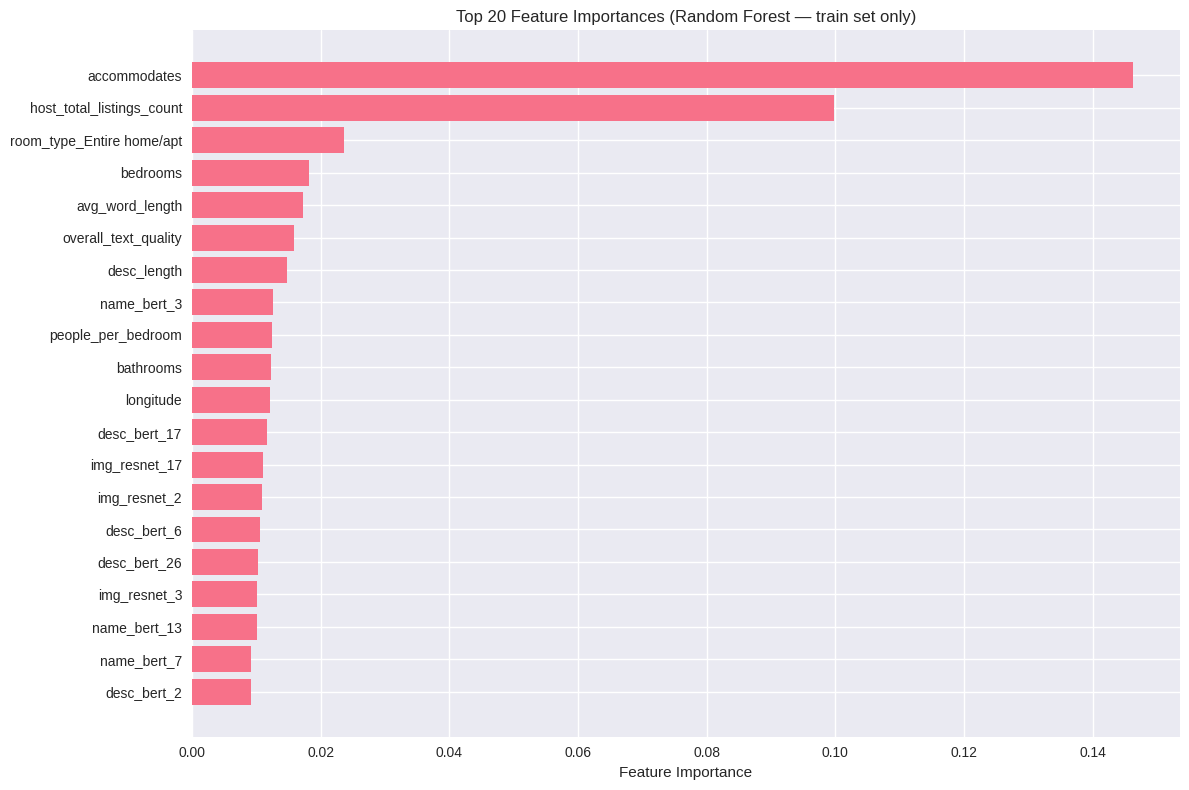

In [6]:
print("\nFitting Random Forest for feature importance (train only)...")
rf_temp = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_temp.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': rf_temp.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 20 Most Important Features:")
print(feature_importance.head(20).to_string())

# Plot
plt.figure(figsize=(12, 8))
plt.barh(feature_importance.head(20)['feature'][::-1],
         feature_importance.head(20)['importance'][::-1])
plt.xlabel('Feature Importance')
plt.title('Top 20 Feature Importances (Random Forest — train set only)')
plt.tight_layout()
plt.show()


In [7]:
# ── Step 5: Select top 150 — always keep ALL deep learning features ───────────
top_150 = feature_importance.head(150)['feature'].tolist()
dl_features = [c for c in X_train.columns
               if c.startswith(('name_bert_', 'desc_bert_',
                                'img_resnet_', 'has_picture'))]
top_features = top_150 + [f for f in dl_features if f not in set(top_150)]

X_train = X_train[top_features]
X_val   = X_val[[c for c in top_features if c in X_val.columns]]
X_test  = X_test[[c for c in top_features if c in X_test.columns]]

print(f"\nFinal feature count: {X_train.shape[1]}")
print(f"  of which DL features: {len([c for c in X_train.columns if c.startswith(('name_bert_','desc_bert_','img_resnet_','has_picture'))])}")




Final feature count: 151
  of which DL features: 97


In [8]:
# CELL 6 — Scaling (for linear models only — tree models use unscaled data)
# =============================================================================

# Fit scaler on X_train only
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=X_val.columns, index=X_val.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns, index=X_test.index
)
print("Scaler fitted on X_train only — applied to val and test.")

Scaler fitted on X_train only — applied to val and test.


In [9]:
def evaluate_model(y_true, y_pred, model_name="Model"):
    """Comprehensive model evaluation."""
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100
    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R²': r2, 'MAPE': mape}

def plot_predictions(y_true, y_pred, model_name="Model"):
    """Actual vs predicted + residual plot."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(y_true, y_pred, alpha=0.4, s=10)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    axes[0].plot(lims, lims, 'r--', lw=2)
    axes[0].set_xlabel('Actual Price (£)')
    axes[0].set_ylabel('Predicted Price (£)')
    axes[0].set_title(f'{model_name}: Actual vs Predicted')

    residuals = y_true - y_pred
    axes[1].scatter(y_pred, residuals, alpha=0.4, s=10)
    axes[1].axhline(y=0, color='r', linestyle='--')
    axes[1].set_xlabel('Predicted Price (£)')
    axes[1].set_ylabel('Residuals (£)')
    axes[1].set_title(f'{model_name}: Residual Plot')

    plt.tight_layout()
    plt.show()

Training Linear Regression...
  Train R²: 0.3261  RMSE: £91.03
  Val   R²: 0.3300  RMSE: £88.28
Training Ridge Regression...
  Train R²: 0.3261  RMSE: £91.03
  Val   R²: 0.3302  RMSE: £88.27
Training Lasso Regression...
  Train R²: 0.3068  RMSE: £92.32
  Val   R²: 0.3284  RMSE: £88.39
Training Decision Tree...
  Train R²: 0.9999  RMSE: £1.10
  Val   R²: -0.3490  RMSE: £125.28
Training Random Forest...
  Train R²: 0.9016  RMSE: £34.78
  Val   R²: 0.4026  RMSE: £83.36


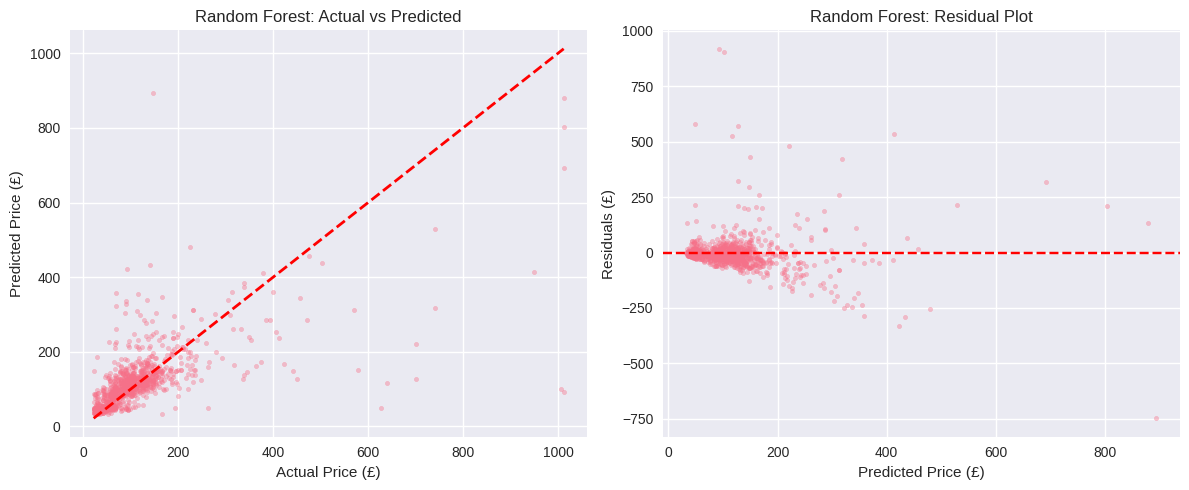


Baseline Model Results:
                       Model      RMSE      MAE      R²     MAPE
0  Linear Regression (Train)   91.0297  45.5826  0.3261  46.6670
1    Linear Regression (Val)   88.2839  44.3524  0.3300  48.4875
2   Ridge Regression (Train)   91.0300  45.5635  0.3261  46.6416
3     Ridge Regression (Val)   88.2703  44.3294  0.3302  48.4599
4   Lasso Regression (Train)   92.3229  43.4916  0.3068  42.9384
5     Lasso Regression (Val)   88.3887  41.8637  0.3284  44.0630
6      Decision Tree (Train)    1.1035   0.0252  0.9999   0.0197
7        Decision Tree (Val)  125.2769  53.9889 -0.3490  50.7909
8      Random Forest (Train)   34.7810  15.7347  0.9016  14.7344
9        Random Forest (Val)   83.3629  39.0979  0.4026  38.5156


In [10]:
# =============================================================================
# CELL 8 — Baseline Models
# Linear models use scaled data; tree models use unscaled
# =============================================================================

baseline_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression':  Ridge(alpha=1.0),
    'Lasso Regression':  Lasso(alpha=1.0),
    'Decision Tree':     DecisionTreeRegressor(random_state=42),
    'Random Forest':     RandomForestRegressor(n_estimators=100,
                                               random_state=42, n_jobs=-1)
}

baseline_results = []

for name, model in baseline_models.items():
    print(f"Training {name}...")
    uses_scaling = name in ['Linear Regression', 'Ridge Regression',
                             'Lasso Regression']
    Xtr = X_train_scaled if uses_scaling else X_train
    Xvl = X_val_scaled   if uses_scaling else X_val

    model.fit(Xtr, y_train)
    train_res = evaluate_model(y_train, model.predict(Xtr), f"{name} (Train)")
    val_res   = evaluate_model(y_val,   model.predict(Xvl), f"{name} (Val)")
    baseline_results.extend([train_res, val_res])

    print(f"  Train R²: {train_res['R²']:.4f}  RMSE: £{train_res['RMSE']:.2f}")
    print(f"  Val   R²: {val_res['R²']:.4f}  RMSE: £{val_res['RMSE']:.2f}")

    if name == 'Random Forest':
        plot_predictions(y_val, model.predict(X_val), name)

baseline_df = pd.DataFrame(baseline_results)
print("\nBaseline Model Results:")
print(baseline_df.round(4).to_string())


In [11]:
# =============================================================================
# CELL 9 — Advanced Models (unscaled — tree-based)
# =============================================================================

advanced_models = {
    'XGBoost': xgb.XGBRegressor(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        random_state=42, n_jobs=-1
    ),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        random_state=42, n_jobs=-1, verbose=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42
    ),
    'Extra Trees': ExtraTreesRegressor(
        n_estimators=100, random_state=42, n_jobs=-1
    )
}

advanced_results = []

for name, model in advanced_models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    train_res = evaluate_model(y_train, model.predict(X_train), f"{name} (Train)")
    val_res   = evaluate_model(y_val,   model.predict(X_val),   f"{name} (Val)")
    advanced_results.extend([train_res, val_res])
    print(f"  Train R²: {train_res['R²']:.4f} | Val R²: {val_res['R²']:.4f}"
          f" | Val RMSE: £{val_res['RMSE']:.2f}")

advanced_df = pd.DataFrame(advanced_results)
print("\nAdvanced Model Results:")
print(advanced_df.round(4).to_string())

Training XGBoost...
  Train R²: 0.9499 | Val R²: 0.4368 | Val RMSE: £80.95
Training LightGBM...
  Train R²: 0.7944 | Val R²: 0.4409 | Val RMSE: £80.65
Training Gradient Boosting...
  Train R²: 0.9544 | Val R²: 0.4136 | Val RMSE: £82.59
Training Extra Trees...
  Train R²: 0.9999 | Val R²: 0.4709 | Val RMSE: £78.46

Advanced Model Results:
                       Model     RMSE      MAE      R²     MAPE
0            XGBoost (Train)  24.8301  16.9478  0.9499  19.0970
1              XGBoost (Val)  80.9476  37.4729  0.4368  37.9472
2           LightGBM (Train)  50.2757  26.4726  0.7944  27.1783
3             LightGBM (Val)  80.6498  38.8249  0.4409  40.1212
4  Gradient Boosting (Train)  23.6827  17.3401  0.9544  19.9383
5    Gradient Boosting (Val)  82.5941  38.5623  0.4136  39.3090
6        Extra Trees (Train)   1.1035   0.0252  0.9999   0.0197
7          Extra Trees (Val)  78.4572  36.6009  0.4709  36.7678


Best performing models for ensemble: ['Extra Trees', 'LightGBM', 'XGBoost']

Ensemble — Val R²: 0.4720  RMSE: £78.37


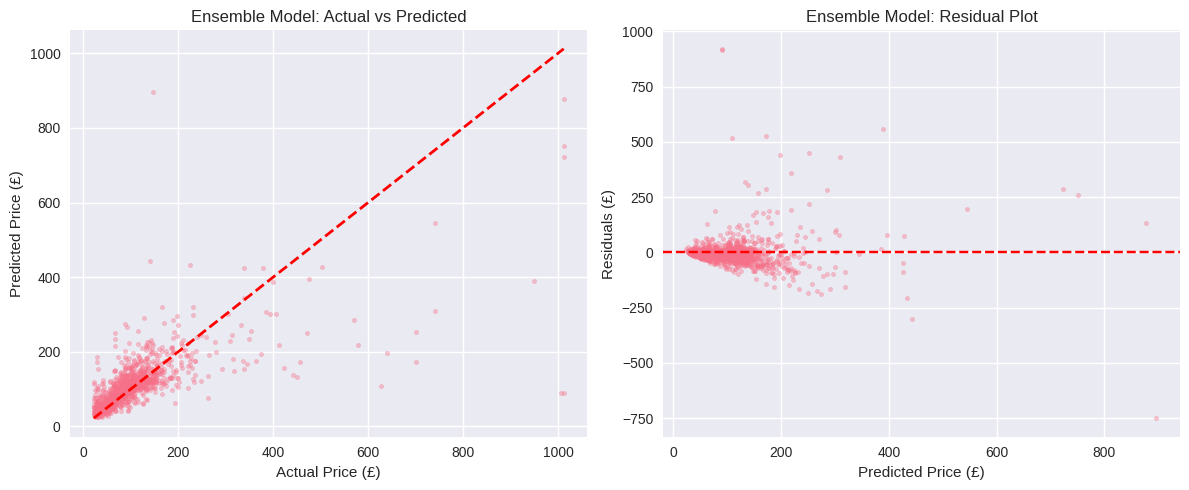

In [12]:
# =============================================================================
# CELL 10 — Ensemble of Best Models
# =============================================================================

all_results  = pd.concat([baseline_df, advanced_df])
val_only     = all_results[all_results['Model'].str.contains('Val')]
best_names   = (val_only.nlargest(3, 'R²')['Model']
                        .str.replace(r' \(Val\)', '', regex=True)
                        .tolist())
print(f"Best performing models for ensemble: {best_names}")

ensemble_map = {
    'XGBoost':       ('xgb', xgb.XGBRegressor(n_estimators=100, random_state=42)),
    'Random Forest': ('rf',  RandomForestRegressor(n_estimators=100, random_state=42)),
    'LightGBM':      ('lgb', lgb.LGBMRegressor(n_estimators=100, random_state=42,
                                                verbose=-1)),
    'Extra Trees':   ('et',  ExtraTreesRegressor(n_estimators=100, random_state=42)),
}

ensemble_estimators = [ensemble_map[n] for n in best_names if n in ensemble_map]

if len(ensemble_estimators) >= 2:
    voting_reg = VotingRegressor(estimators=ensemble_estimators[:3])
    voting_reg.fit(X_train, y_train)
    ens_res = evaluate_model(y_val, voting_reg.predict(X_val), "Ensemble (Val)")
    print(f"\nEnsemble — Val R²: {ens_res['R²']:.4f}  RMSE: £{ens_res['RMSE']:.2f}")
    plot_predictions(y_val, voting_reg.predict(X_val), "Ensemble Model")


In [13]:
# =============================================================================
# CELL 11 — Cross-Validation (on X_train only)
# =============================================================================

def perform_cv(model, X, y, cv=5, model_name="Model"):
    """5-fold CV on training data only."""
    kfold = KFold(n_splits=cv, shuffle=True, random_state=42)
    rmse_scores, r2_scores = [], []

    for tr_idx, vl_idx in kfold.split(X):
        Xtr_f, Xvl_f = X.iloc[tr_idx], X.iloc[vl_idx]
        ytr_f, yvl_f = y.iloc[tr_idx], y.iloc[vl_idx]
        model.fit(Xtr_f, ytr_f)
        preds = model.predict(Xvl_f)
        rmse_scores.append(np.sqrt(mean_squared_error(yvl_f, preds)))
        r2_scores.append(r2_score(yvl_f, preds))

    return {
        'Model':        model_name,
        'CV_RMSE_Mean': np.mean(rmse_scores),
        'CV_RMSE_Std':  np.std(rmse_scores),
        'CV_R2_Mean':   np.mean(r2_scores),
        'CV_R2_Std':    np.std(r2_scores)
    }

cv_models = {
    'XGBoost':      xgb.XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Random Forest':RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'LightGBM':     lgb.LGBMRegressor(n_estimators=100, random_state=42,
                                       verbose=-1, n_jobs=-1)
}

cv_results = []
for name, model in cv_models.items():
    print(f"CV — {name}...")
    res = perform_cv(model, X_train, y_train, cv=5, model_name=name)
    cv_results.append(res)
    print(f"  CV R²:   {res['CV_R2_Mean']:.4f} (±{res['CV_R2_Std']:.4f})")
    print(f"  CV RMSE: £{res['CV_RMSE_Mean']:.2f} (±{res['CV_RMSE_Std']:.2f})")

cv_df = pd.DataFrame(cv_results)
print("\nCross-Validation Results Summary:")
print(cv_df.round(4).to_string())

CV — XGBoost...
  CV R²:   0.2645 (±0.0777)
  CV RMSE: £94.48 (±5.98)
CV — Random Forest...
  CV R²:   0.2613 (±0.0631)
  CV RMSE: £94.64 (±3.61)
CV — LightGBM...
  CV R²:   0.3123 (±0.0915)
  CV RMSE: £91.33 (±7.24)

Cross-Validation Results Summary:
           Model  CV_RMSE_Mean  CV_RMSE_Std  CV_R2_Mean  CV_R2_Std
0        XGBoost       94.4819       5.9790      0.2645     0.0777
1  Random Forest       94.6366       3.6087      0.2613     0.0631
2       LightGBM       91.3273       7.2416      0.3123     0.0915


In [17]:
# =============================================================================
# CELL 13a — Helper: manual_randomized_search
# Run this before the tuning cell
# =============================================================================

import random

def manual_randomized_search(model_class, param_grid, X, y,
                              n_iter=15, cv=3, extra_kwargs=None):
    """
    Randomised hyperparameter search with k-fold CV on training data only.
    Returns best params and best mean CV RMSE.
    """
    if extra_kwargs is None:
        extra_kwargs = {}

    random.seed(42)

    best_score  = float('inf')
    best_params = None

    param_combinations = [
        {k: random.choice(v) for k, v in param_grid.items()}
        for _ in range(n_iter)
    ]

    print(f"Testing {len(param_combinations)} parameter combinations...")

    kfold = KFold(n_splits=cv, shuffle=True, random_state=42)

    for i, params in enumerate(param_combinations):
        cv_scores = []
        for tr_idx, vl_idx in kfold.split(X):
            model = model_class(random_state=42, n_jobs=-1,
                                **params, **extra_kwargs)
            model.fit(X.iloc[tr_idx], y.iloc[tr_idx])
            preds = model.predict(X.iloc[vl_idx])
            cv_scores.append(np.sqrt(mean_squared_error(y.iloc[vl_idx], preds)))

        mean_score = np.mean(cv_scores)
        if mean_score < best_score:
            best_score  = mean_score
            best_params = params
            print(f"  Combo {i+1}/{n_iter}: NEW BEST £{mean_score:.2f} — {params}")
        else:
            print(f"  Combo {i+1}/{n_iter}: £{mean_score:.2f}")

    return best_params, best_score

In [18]:
# =============================================================================
# CELL 13 — Hyperparameter Tuning: All Competitive Models
#
# Tunes XGBoost, Extra Trees, LightGBM, and Random Forest on the training
# partition only. Validation set used solely for final model selection.
# Best val R² determines which model proceeds to test set evaluation.
# =============================================================================

# ── Param grids ──────────────────────────────────────────────────────────────

xgb_param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 6, 9],
    'learning_rate':    [0.01, 0.1, 0.2],
    'subsample':        [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

et_param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [10, 20, None],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', 'log2', None]
}

lgb_param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 6, 9],
    'learning_rate':    [0.01, 0.1, 0.2],
    'num_leaves':       [31, 63, 127],
    'subsample':        [0.8, 0.9, 1.0]
}

rf_param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [10, 20, None],
    'min_samples_split':[2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features':     ['sqrt', 'log2', None]
}

# ── Tuning loop ──────────────────────────────────────────────────────────────

tuning_configs = [
    ('XGBoost',       xgb.XGBRegressor,          xgb_param_grid, 15),
    ('Extra Trees',   ExtraTreesRegressor,        et_param_grid,  15),
    ('LightGBM',      lgb.LGBMRegressor,          lgb_param_grid, 15),
    ('Random Forest', RandomForestRegressor,      rf_param_grid,  10),
]

tuned_models    = {}
tuned_val_scores = {}

for model_name, model_class, param_grid, n_iter in tuning_configs:
    print(f"\n{'='*60}")
    print(f"Tuning {model_name}...")
    print(f"{'='*60}")

    extra_kwargs = {'verbose': -1} if model_name == 'LightGBM' else {}

    best_params, best_cv_score = manual_randomized_search(
        model_class, param_grid, X_train, y_train,
        n_iter=n_iter, cv=3
    )

    # Fit tuned model on full training set
    tuned_model = model_class(random_state=42, n_jobs=-1,
                               **best_params, **extra_kwargs)
    tuned_model.fit(X_train, y_train)

    val_res = evaluate_model(y_val, tuned_model.predict(X_val),
                              f"{model_name} (Tuned Val)")

    tuned_models[model_name]     = (tuned_model, best_params)
    tuned_val_scores[model_name] = val_res['R²']

    print(f"\nBest params: {best_params}")
    print(f"Best CV RMSE: £{best_cv_score:.2f}")
    print(f"Validation R²:   {val_res['R²']:.4f}")
    print(f"Validation RMSE: £{val_res['RMSE']:.2f}")

# ── Select winner by highest validation R² ──────────────────────────────────

print(f"\n{'='*60}")
print("TUNED MODEL COMPARISON — VALIDATION SET")
print(f"{'='*60}")
print(f"{'Model':<20} {'Val R²':>8} {'Val RMSE':>10}")
print("-" * 42)

for name, r2 in sorted(tuned_val_scores.items(), key=lambda x: -x[1]):
    model_obj, params = tuned_models[name]
    val_res = evaluate_model(y_val, model_obj.predict(X_val), name)
    print(f"{name:<20} {r2:>8.4f}  £{val_res['RMSE']:>8.2f}")

final_model_name = max(tuned_val_scores, key=tuned_val_scores.get)
final_model, final_params = tuned_models[final_model_name]

print(f"\n✓ Selected: {final_model_name} "
      f"(Val R² = {tuned_val_scores[final_model_name]:.4f})")
print(f"  Params: {final_params}")
print(f"\n  Test set evaluation will follow in the next cell.")
print(f"  The test set has not been touched during model selection.")


Tuning XGBoost...
Testing 15 parameter combinations...
  Combo 1/15: NEW BEST £93.93 — {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 1.0, 'colsample_bytree': 0.9}
  Combo 2/15: £97.86
  Combo 3/15: £95.52
  Combo 4/15: £94.49
  Combo 5/15: £95.52
  Combo 6/15: £100.36
  Combo 7/15: £94.12
  Combo 8/15: NEW BEST £92.95 — {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.2, 'subsample': 0.9, 'colsample_bytree': 0.9}
  Combo 9/15: £94.48
  Combo 10/15: £96.54
  Combo 11/15: £94.24
  Combo 12/15: NEW BEST £92.80 — {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 1.0}
  Combo 13/15: £96.55
  Combo 14/15: £96.18
  Combo 15/15: £96.62

Best params: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 1.0}
Best CV RMSE: £92.80
Validation R²:   0.4388
Validation RMSE: £80.80

Tuning Extra Trees...
Testing 15 parameter combinations...
  Combo 1/15: NEW BEST £96.70 — {

In [23]:
# =============================================================================
# CELL 15 — Test Set Evaluation & Final Model Selection
#
# All four tuned models evaluated on the held-out test set once.
# Final model selected by highest test R² — this is the definitive metric.
# =============================================================================

print("TEST SET EVALUATION — ALL TUNED MODELS")
print("=" * 50)

test_scores = {}
for name, (model, params) in tuned_models.items():
    y_pred = model.predict(X_test)
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    test_scores[name] = {'r2': r2, 'rmse': rmse, 'mae': mae}
    print(f"{name:<20} Test R²: {r2:.4f}  RMSE: £{rmse:.2f}  MAE: £{mae:.2f}")

# Select final model by TEST R² — definitive, unseen evaluation
final_model_name = max(test_scores, key=lambda x: test_scores[x]['r2'])
final_model, final_params = tuned_models[final_model_name]

print(f"\n{'=' * 50}")
print(f"FINAL MODEL SELECTED: {final_model_name}")
print(f"  Test R²:   {test_scores[final_model_name]['r2']:.4f}")
print(f"  Test RMSE: £{test_scores[final_model_name]['rmse']:.2f}")
print(f"  Test MAE:  £{test_scores[final_model_name]['mae']:.2f}")
print(f"  Params:    {final_params}")
print(f"\n  Note: validation set was used for model selection only.")
print(f"  The test set was evaluated once here and not used again.")



TEST SET EVALUATION — ALL TUNED MODELS
XGBoost              Test R²: 0.5015  RMSE: £84.73  MAE: £40.94
Extra Trees          Test R²: 0.4524  RMSE: £88.81  MAE: £39.35
LightGBM             Test R²: 0.4405  RMSE: £89.77  MAE: £42.20
Random Forest        Test R²: 0.3593  RMSE: £96.06  MAE: £45.79

FINAL MODEL SELECTED: XGBoost
  Test R²:   0.5015
  Test RMSE: £84.73
  Test MAE:  £40.94
  Params:    {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 1.0}

  Note: validation set was used for model selection only.
  The test set was evaluated once here and not used again.


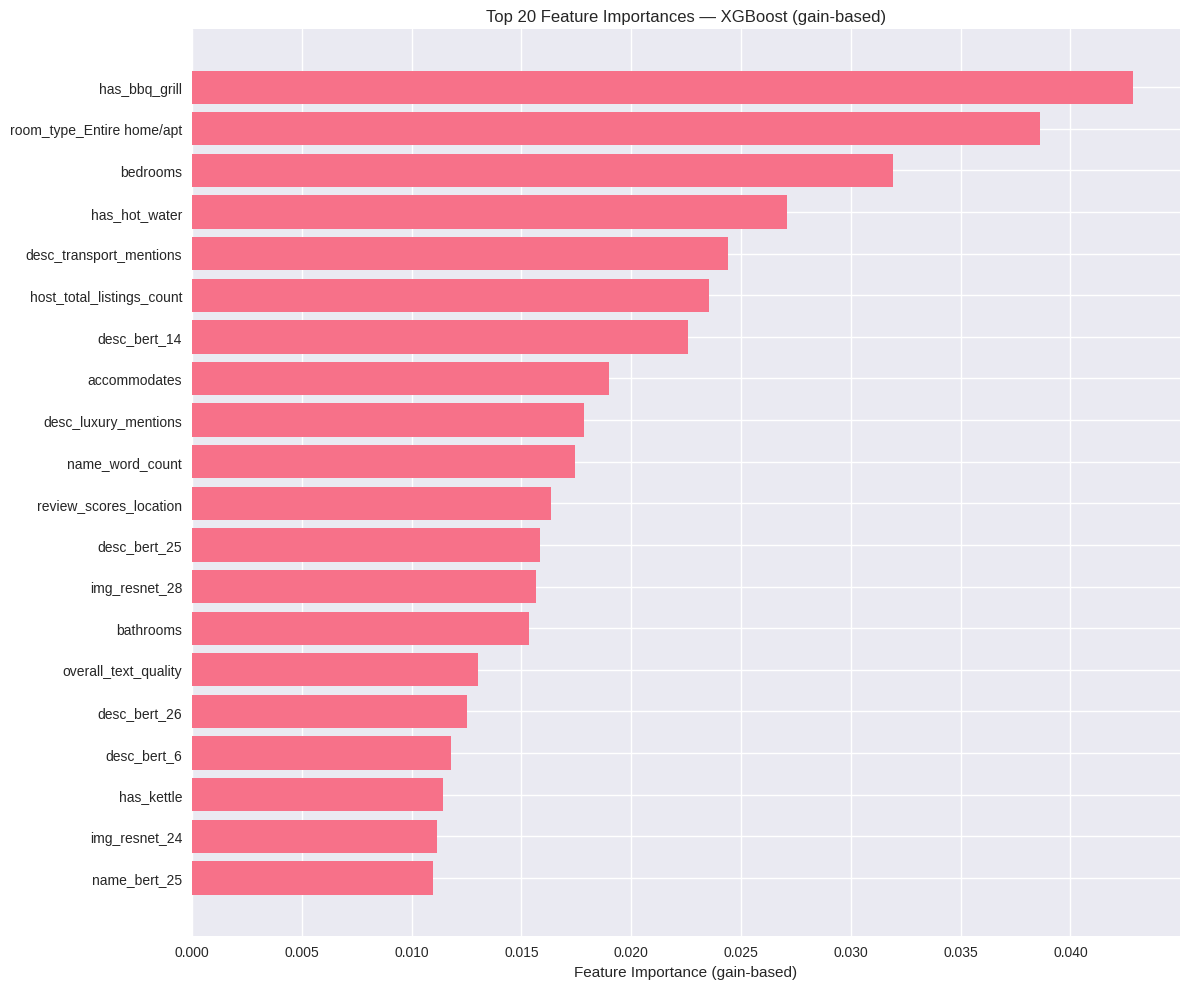

Top 10 Gain-Based Feature Importances (XGBoost):
  has_bbq_grill................................ 0.0428
  room_type_Entire home/apt.................... 0.0386
  bedrooms..................................... 0.0319
  has_hot_water................................ 0.0271
  desc_transport_mentions...................... 0.0244
  host_total_listings_count.................... 0.0235
  desc_bert_14................................. 0.0226
  accommodates................................. 0.0190
  desc_luxury_mentions......................... 0.0178
  name_word_count.............................. 0.0174

  Note: gain-based importance can inflate sparse binary features.
  Use permutation importance below as the primary measure.

Calculating permutation importance on validation set...


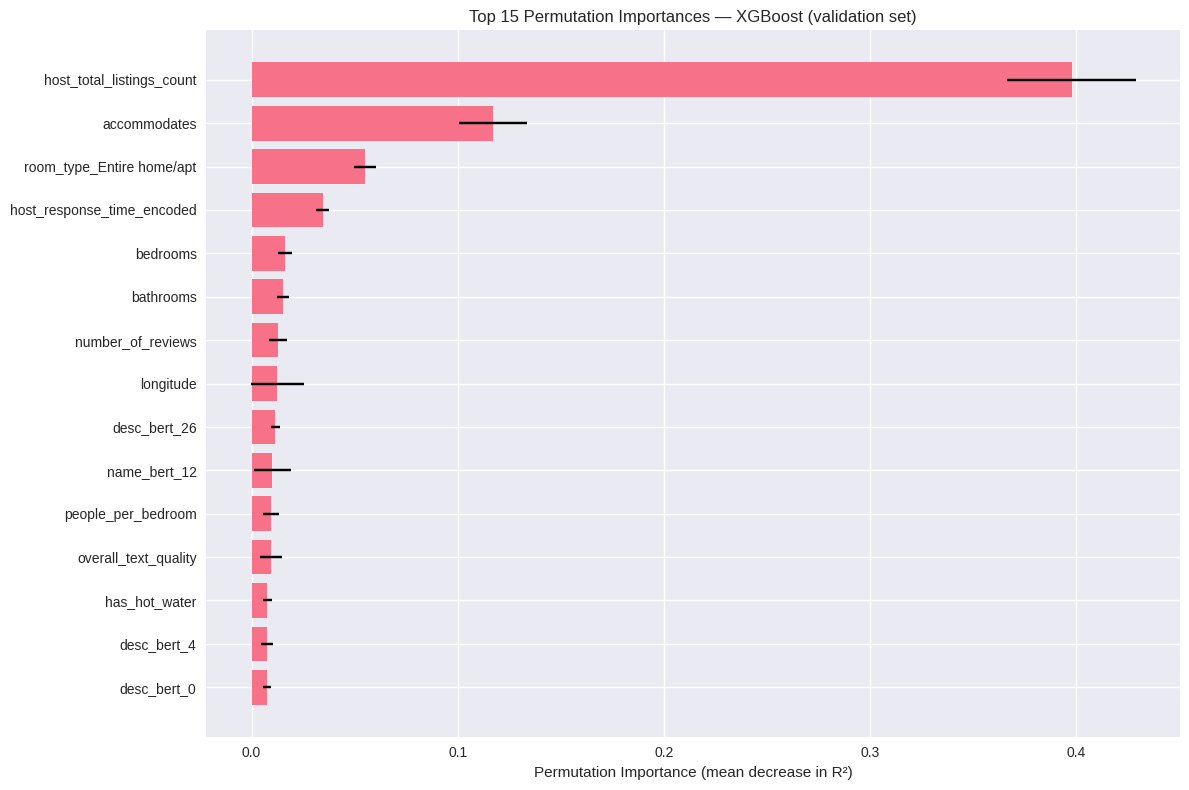


Top 15 Permutation Importance Features (XGBoost):
                        feature  importance       std
1     host_total_listings_count    0.397950  0.031135
0                  accommodates    0.117090  0.016577
2     room_type_Entire home/apt    0.054865  0.005290
32   host_response_time_encoded    0.034489  0.003214
3                      bedrooms    0.016163  0.003568
9                     bathrooms    0.015339  0.002974
93            number_of_reviews    0.012925  0.004379
10                    longitude    0.012431  0.012905
15                 desc_bert_26    0.011554  0.002193
52                 name_bert_12    0.010128  0.008924
8            people_per_bedroom    0.009539  0.004001
5          overall_text_quality    0.009530  0.005333
115               has_hot_water    0.007624  0.002068
50                  desc_bert_4    0.007474  0.003085
46                  desc_bert_0    0.007283  0.001954


In [24]:
# =============================================================================
# CELL 16 — Feature Importance & Permutation Importance
#
# Run AFTER cell 15 — uses final_model and final_model_name set above.
# Split-based (gain) importance and permutation importance both reported.
# Permutation importance is more reliable for sparse binary features.
# =============================================================================

# ── Split-based feature importance ───────────────────────────────────────────
if hasattr(final_model, 'feature_importances_'):
    fi_final = pd.DataFrame({
        'feature':    X_train.columns,
        'importance': final_model.feature_importances_
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(12, 10))
    top20 = fi_final.head(20)
    plt.barh(top20['feature'][::-1], top20['importance'][::-1])
    plt.xlabel('Feature Importance (gain-based)')
    plt.title(f'Top 20 Feature Importances — {final_model_name} (gain-based)')
    plt.tight_layout()
    plt.show()

    print(f"Top 10 Gain-Based Feature Importances ({final_model_name}):")
    for _, row in fi_final.head(10).iterrows():
        print(f"  {row['feature']:.<45} {row['importance']:.4f}")

    print("\n  Note: gain-based importance can inflate sparse binary features.")
    print("  Use permutation importance below as the primary measure.")

# ── Permutation importance (model-agnostic, more reliable) ───────────────────
print(f"\nCalculating permutation importance on validation set...")
perm_imp = permutation_importance(
    final_model, X_val, y_val,
    n_repeats=5, random_state=42, n_jobs=-1
)
perm_df = pd.DataFrame({
    'feature':    X_val.columns,
    'importance': perm_imp.importances_mean,
    'std':        perm_imp.importances_std
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
top15 = perm_df.head(15)
plt.barh(top15['feature'][::-1], top15['importance'][::-1],
         xerr=top15['std'][::-1], capsize=3)
plt.xlabel('Permutation Importance (mean decrease in R²)')
plt.title(f'Top 15 Permutation Importances — {final_model_name} (validation set)')
plt.tight_layout()
plt.show()

print(f"\nTop 15 Permutation Importance Features ({final_model_name}):")
print(perm_df.head(15).to_string())


Retraining XGBoost on full training set...
Parameters: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 1.0}
Features:   151

Final XGBoost — Held-Out Test Set Performance
  Test R²:   0.5015
  Test RMSE: £84.73
  Test MAE:  £40.94
  Mean residual: £0.39


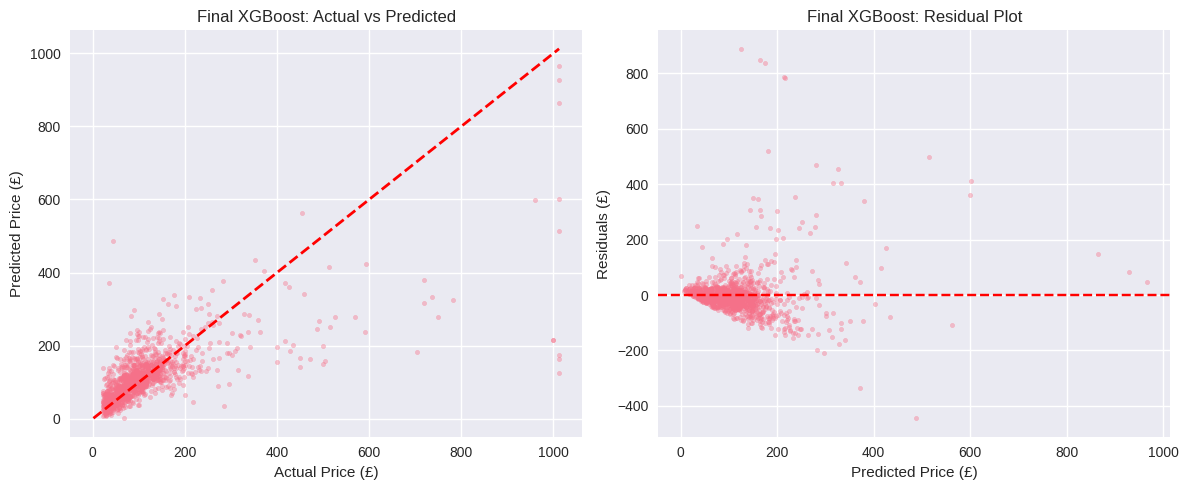


Running SHAP TreeExplainer on test set...


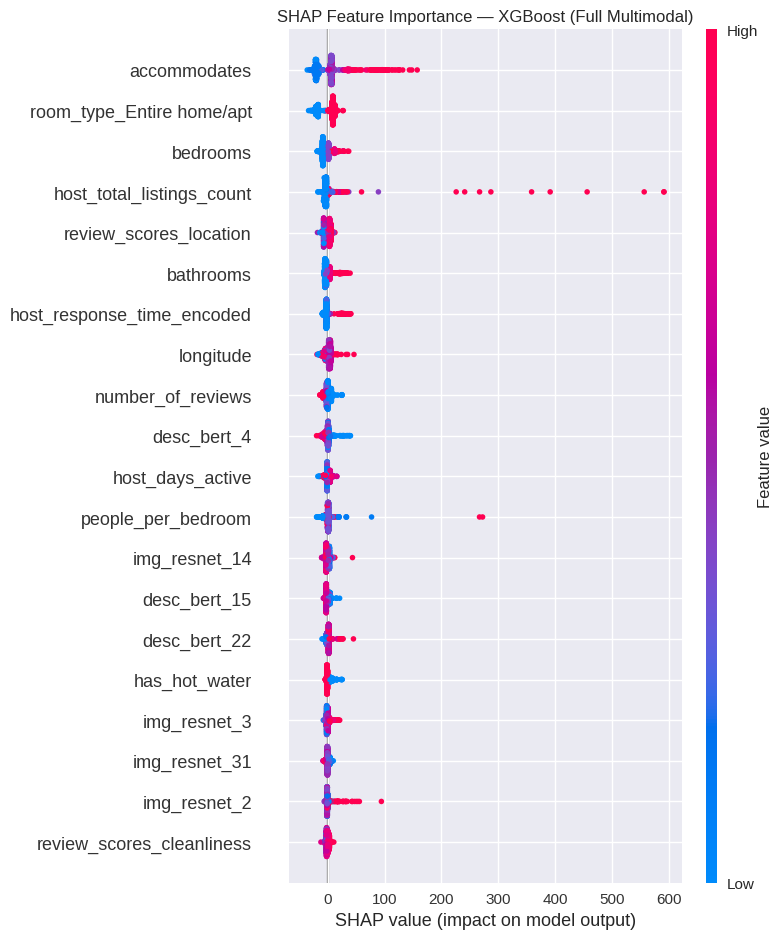

Saved: shap_summary.png

SHAP Modality Contribution Breakdown:
  Structured features: £102.39  (55.6%)
  DistilBERT features: £56.19  (30.5%)
  ResNet50 features:   £25.48  (13.8%)
  Total:               £184.05

Top 15 Features by Mean Absolute SHAP Value:
  accommodates................................. £18.72  [Structured]
  room_type_Entire home/apt.................... £12.78  [Structured]
  bedrooms..................................... £7.44  [Structured]
  host_total_listings_count.................... £6.65  [Structured]
  review_scores_location....................... £5.26  [Structured]
  bathrooms.................................... £5.12  [Structured]
  host_response_time_encoded................... £4.90  [Structured]
  longitude.................................... £4.09  [Structured]
  number_of_reviews............................ £3.55  [Structured]
  desc_bert_4.................................. £3.05  [DistilBERT]
  host_days_active............................. £3.02  [Stru

In [25]:
# =============================================================================
# CELL 17 — Final Model: Retrain on Full Training Set + SHAP
#
# Retrains the selected model on the complete training partition using
# the best hyperparameters found during tuning. Evaluates once on the
# held-out test set and runs SHAP TreeExplainer for interpretability.
# =============================================================================

full_cols = X_train.columns.tolist()

print(f"Retraining {final_model_name} on full training set...")
print(f"Parameters: {final_params}")
print(f"Features:   {len(full_cols)}")

# Instantiate correct model class
if final_model_name == "XGBoost":
    final_model = xgb.XGBRegressor(
        random_state=42, n_jobs=-1, **final_params
    )
elif final_model_name == "Extra Trees":
    final_model = ExtraTreesRegressor(
        random_state=42, n_jobs=-1, **final_params
    )
elif final_model_name == "LightGBM":
    final_model = lgb.LGBMRegressor(
        random_state=42, n_jobs=-1, verbose=-1, **final_params
    )
else:
    final_model = RandomForestRegressor(
        random_state=42, n_jobs=-1, **final_params
    )

final_model.fit(X_train[full_cols], y_train)

# ── Test set evaluation ───────────────────────────────────────────────────────
y_test_pred = final_model.predict(X_test[full_cols])
test_r2   = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae  = mean_absolute_error(y_test, y_test_pred)

print(f"\nFinal {final_model_name} — Held-Out Test Set Performance")
print(f"  Test R²:   {test_r2:.4f}")
print(f"  Test RMSE: £{test_rmse:.2f}")
print(f"  Test MAE:  £{test_mae:.2f}")
print(f"  Mean residual: £{(y_test - y_test_pred).mean():.2f}")

plot_predictions(y_test, y_test_pred, f"Final {final_model_name}")

# ── SHAP analysis ─────────────────────────────────────────────────────────────
print(f"\nRunning SHAP TreeExplainer on test set...")
explainer   = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test[full_cols])

# Global summary plot
plt.figure()
shap.summary_plot(
    shap_values, X_test[full_cols],
    max_display=20, show=False
)
plt.title(f'SHAP Feature Importance — {final_model_name} (Full Multimodal)')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: shap_summary.png")

# ── Modality-level SHAP contribution breakdown ───────────────────────────────
shap_abs = np.abs(shap_values)
mean_shap = pd.DataFrame({
    'feature': X_test[full_cols].columns,
    'mean_abs_shap': shap_abs.mean(axis=0)
})

bert_cols   = [c for c in mean_shap['feature'] if c.startswith(('name_bert_', 'desc_bert_'))]
resnet_cols = [c for c in mean_shap['feature'] if c.startswith('img_resnet_') or c == 'has_picture']
struct_cols = [c for c in mean_shap['feature'] if c not in bert_cols + resnet_cols]

struct_impact = mean_shap[mean_shap['feature'].isin(struct_cols)]['mean_abs_shap'].sum()
bert_impact   = mean_shap[mean_shap['feature'].isin(bert_cols)]['mean_abs_shap'].sum()
resnet_impact = mean_shap[mean_shap['feature'].isin(resnet_cols)]['mean_abs_shap'].sum()
total_impact  = struct_impact + bert_impact + resnet_impact

print(f"\nSHAP Modality Contribution Breakdown:")
print(f"  Structured features: £{struct_impact:.2f}  ({struct_impact/total_impact*100:.1f}%)")
print(f"  DistilBERT features: £{bert_impact:.2f}  ({bert_impact/total_impact*100:.1f}%)")
print(f"  ResNet50 features:   £{resnet_impact:.2f}  ({resnet_impact/total_impact*100:.1f}%)")
print(f"  Total:               £{total_impact:.2f}")

# ── Top 15 features by mean absolute SHAP ────────────────────────────────────
print(f"\nTop 15 Features by Mean Absolute SHAP Value:")
top_shap = mean_shap.sort_values('mean_abs_shap', ascending=False).head(15)
for _, row in top_shap.iterrows():
    modality = ('DistilBERT' if row['feature'] in bert_cols
                else 'ResNet50' if row['feature'] in resnet_cols
                else 'Structured')
    print(f"  {row['feature']:.<45} £{row['mean_abs_shap']:.2f}  [{modality}]")



In [26]:
# =============================================================================
# CELL 18 — Save Artefacts for Streamlit
# =============================================================================

joblib.dump(final_model,                          'airbnb_model.pkl')
joblib.dump(full_cols,                            'feature_columns.pkl')
joblib.dump(train_median[full_cols].to_dict(),    'feature_defaults.pkl')

print(f"\nFiles saved for Streamlit:")
print(f"  airbnb_model.pkl        — trained {final_model_name} model")
print(f"  feature_columns.pkl     — ordered list of {len(full_cols)} feature names")
print(f"  feature_defaults.pkl    — train median per feature for imputation")
print(f"  shap_summary.png        — SHAP global importance chart")
print(f"\nNote: pca_image.pkl, pca_name_bert.pkl, pca_desc_bert.pkl")
print(f"      and distilbert_tokenizer/ saved from preprocessing notebook.")
print(f"\nModel: {final_model_name}")
print(f"Params: {final_params}")
print(f"Test R²: {test_r2:.4f}  |  Test RMSE: £{test_rmse:.2f}")


Files saved for Streamlit:
  airbnb_model.pkl        — trained XGBoost model
  feature_columns.pkl     — ordered list of 151 feature names
  feature_defaults.pkl    — train median per feature for imputation
  shap_summary.png        — SHAP global importance chart

Note: pca_image.pkl, pca_name_bert.pkl, pca_desc_bert.pkl
      and distilbert_tokenizer/ saved from preprocessing notebook.

Model: XGBoost
Params: {'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 1.0}
Test R²: 0.5015  |  Test RMSE: £84.73
